# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Maria Putu Evelyne Corena Puryatma | 5054251011 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Breast Cancer Wisconsin (Diagnostic) Data Set (Kaggle)](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [ ]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore', category=RuntimeWarning, message='.*encountered in matmul')

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
data = pd.read_csv("data.csv")
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [3]:
print('Jumlah baris dan kolom:', data.shape)
print()
data.info()
print('\nJumlah missing value per kolom:')
print(data.isnull().sum().to_string())
data.describe().T

Jumlah baris dan kolom: (569, 33)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    floa

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


Distribusi label diagnosis:
diagnosis
B    357
M    212

Kelas mayoritas: B (62.7% dari seluruh data)


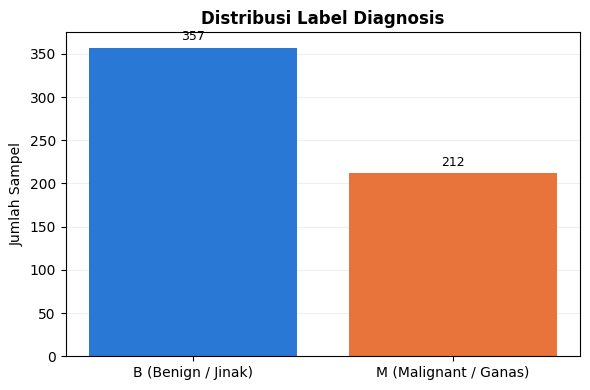

In [4]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

diagnosis_counts = data['diagnosis'].value_counts()[['B', 'M']]

print('Distribusi label diagnosis:')
print(diagnosis_counts.to_string())
print(f'\nKelas mayoritas: {diagnosis_counts.idxmax()} '
      f'({diagnosis_counts.max() / len(data) * 100:.1f}% dari seluruh data)')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['B (Benign / Jinak)', 'M (Malignant / Ganas)'], diagnosis_counts.values, color=['#2a78d6', '#e8743b'])
ax.set_ylabel('Jumlah Sampel')
ax.set_title('Distribusi Label Diagnosis', fontsize=12, fontweight='bold')
for i, v in enumerate(diagnosis_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', color='#f0efec', lw=.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

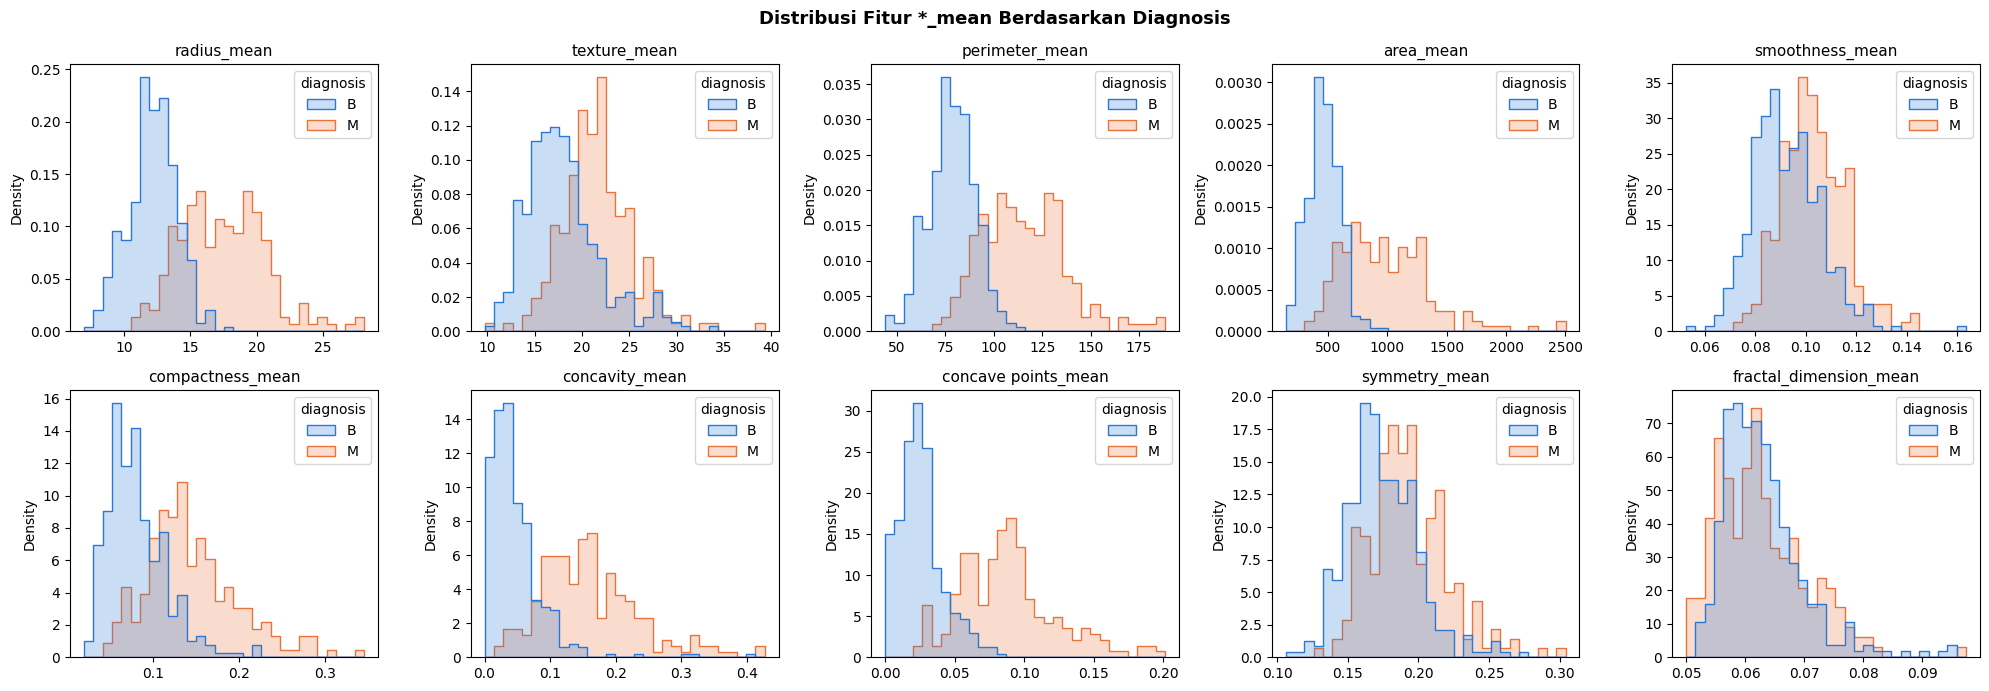

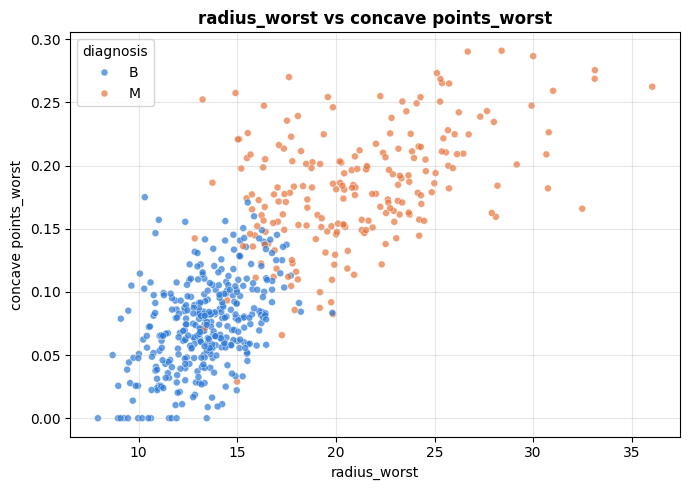

In [5]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas (linear) antar kelas, atau justru tumpang tindih.

# 10 fitur *_mean dibandingkan antar kelas memakai histogram (density, supaya kelas kecil tetap terlihat).
fitur_mean = [c for c in data.columns if c.endswith('_mean')]

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, fitur in zip(axes.flatten(), fitur_mean):
    sns.histplot(data=data, x=fitur, hue='diagnosis', hue_order=['B', 'M'], bins=30, stat='density',
                 common_norm=False, element='step', palette=['#2a78d6', '#e8743b'], ax=ax)
    ax.set_title(fitur, fontsize=11)
    ax.set_xlabel('')
plt.suptitle('Distribusi Fitur *_mean Berdasarkan Diagnosis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Scatter plot dua fitur dengan korelasi tertinggi terhadap target, untuk melihat apakah kelas bisa dipisah dengan garis lurus.
plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x='radius_worst', y='concave points_worst', hue='diagnosis', hue_order=['B', 'M'],
                palette=['#2a78d6', '#e8743b'], alpha=0.7, s=25)
plt.title('radius_worst vs concave points_worst', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

Jumlah baris duplikat: 0


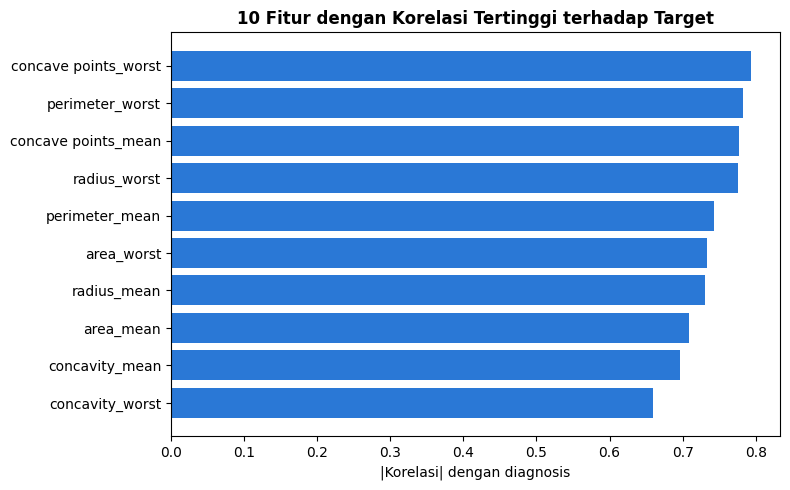

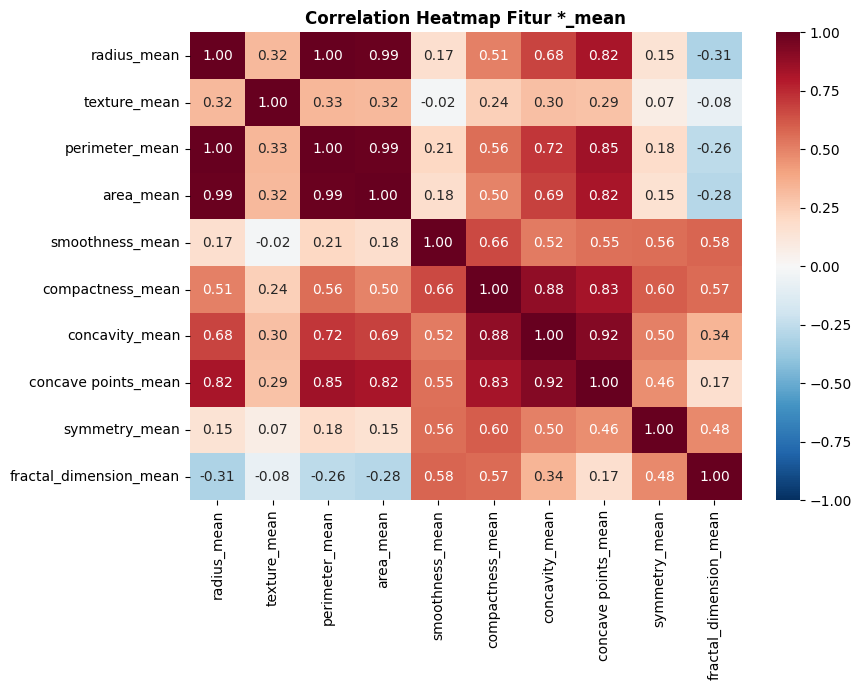


3 fitur dengan rentang terbesar dan 3 fitur dengan rentang terkecil:


,min,max,range
area_worst,185.200000,4254.00000,4068.800000
area_mean,143.500000,2501.00000,2357.500000
area_se,6.802000,542.20000,535.398000
fractal_dimension_mean,0.049960,0.09744,0.047480
smoothness_se,0.001713,0.03113,0.029417
fractal_dimension_se,0.000895,0.02984,0.028945


In [6]:
# EDA tambahan:
# 1) Cek data duplikat
print('Jumlah baris duplikat:', data.duplicated().sum())

# 2) Korelasi (absolut) setiap fitur terhadap target (M = 1, B = 0)
fitur_angka = data.drop(columns=['id', 'diagnosis', 'Unnamed: 32'])
target_angka = (data['diagnosis'] == 'M').astype(int)
korelasi = fitur_angka.corrwith(target_angka).abs().sort_values(ascending=False)

top10 = korelasi.head(10).sort_values()
plt.figure(figsize=(8, 5))
plt.barh(top10.index, top10.values, color='#2a78d6')
plt.xlabel('|Korelasi| dengan diagnosis')
plt.title('10 Fitur dengan Korelasi Tertinggi terhadap Target', fontweight='bold')
plt.tight_layout()
plt.show()

# 3) Correlation heatmap antar fitur *_mean untuk melihat multikolinearitas
plt.figure(figsize=(9, 7))
sns.heatmap(data[fitur_mean].corr(), annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1)
plt.title('Correlation Heatmap Fitur *_mean', fontweight='bold')
plt.tight_layout()
plt.show()

# 4) Rentang nilai fitur. Perbedaan skala yang sangat besar menunjukkan bahwa feature scaling wajib dilakukan untuk SVM.
rentang = fitur_angka.describe().T[['min', 'max']]
rentang['range'] = rentang['max'] - rentang['min']
rentang = rentang.sort_values('range', ascending=False)
print('\n3 fitur dengan rentang terbesar dan 3 fitur dengan rentang terkecil:')
pd.concat([rentang.head(3), rentang.tail(3)])

# 2. Preprocessing

In [7]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

missing = data.isnull().sum()
print('Kolom dengan missing value:')
print(missing[missing > 0].to_string())

# Kolom 'Unnamed: 32' 100% kosong. Kolom ini muncul karena setiap baris di file CSV diakhiri tanda koma,
# jadi bukan fitur sebenarnya. Kolom ini dihapus (bukan diimputasi), sehingga tidak ada data leakage.
# Kolom 'id' juga dihapus karena hanya nomor identitas pasien, tidak punya informasi untuk prediksi.
data = data.drop(columns=['Unnamed: 32', 'id'])

print('\nTotal missing value setelah ditangani:', data.isnull().sum().sum())
print('Ukuran data:', data.shape)

Kolom dengan missing value:
Unnamed: 32    569

Total missing value setelah ditangani: 0
Ukuran data: (569, 31)


In [8]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).

print('Tipe data yang ada:')
print(data.dtypes.value_counts())

# Satu-satunya kolom kategorikal adalah target 'diagnosis'. Karena hanya 2 kelas, cukup diubah ke 0/1:
# M (Malignant/ganas) = 1, yaitu kelas yang ingin dideteksi, dan B (Benign/jinak) = 0.
# Semua fitur lain sudah numerik, jadi tidak perlu One-Hot Encoding.
data['diagnosis'] = data['diagnosis'].map({'B': 0, 'M': 1})
print('\nDistribusi diagnosis setelah encoding:')
print(data['diagnosis'].value_counts().to_string())

Tipe data yang ada:
float64    30
object      1
Name: count, dtype: int64

Distribusi diagnosis setelah encoding:
diagnosis
0    357
1    212


In [9]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

from sklearn.model_selection import train_test_split

X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Proporsi kelas 1 (M) di train: %.3f | di test: %.3f' % (y_train.mean(), y_test.mean()))

Train: (455, 30) | Test: (114, 30)
Proporsi kelas 1 (M) di train: 0.374 | di test: 0.368


**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [10]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.

from sklearn.preprocessing import StandardScaler

# Semua fitur numerik, jadi semuanya discaling.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

contoh = ['area_worst', 'radius_mean', 'fractal_dimension_se']
idx = [list(X.columns).index(c) for c in contoh]
print('Sebelum scaling (train):')
print(X_train[contoh].describe().loc[['mean', 'std', 'min', 'max']].round(4))
print('\nSesudah scaling (train):')
print(pd.DataFrame(X_train_scaled[:, idx], columns=contoh).describe().loc[['mean', 'std', 'min', 'max']].round(4))

Sebelum scaling (train):
      area_worst  radius_mean  fractal_dimension_se
mean    890.5692      14.1661                0.0038
std     582.3462       3.5791                0.0026
min     185.2000       6.9810                0.0009
max    4254.0000      28.1100                0.0298

Sesudah scaling (train):
      area_worst  radius_mean  fractal_dimension_se
mean     -0.0000      -0.0000               -0.0000
std       1.0011       1.0011                1.0011
min      -1.2126      -2.0097               -1.0921
max       5.7820       3.9002                9.9174


# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [11]:
# Inisialisasi dan latih model SVC dengan kernel='linear' menggunakan train set (yang sudah discaling).

from sklearn.svm import SVC

model_linear = SVC(kernel='linear', C=1.0)
model_linear.fit(X_train_scaled, y_train)
print('Jumlah support vector per kelas [B, M]:', model_linear.n_support_)

Jumlah support vector per kelas [B, M]: [19 19]


In [12]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

from sklearn.metrics import accuracy_score

y_pred_linear = model_linear.predict(X_test_scaled)
print('Train Accuracy Linear:', round(accuracy_score(y_train, model_linear.predict(X_train_scaled)), 4))
print('Test Accuracy Linear :', round(accuracy_score(y_test, y_pred_linear), 4))

Train Accuracy Linear: 0.989
Test Accuracy Linear : 0.9649


## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [13]:
# Inisialisasi dan latih model SVC dengan kernel='rbf' menggunakan train set.
# Gunakan nilai hyperparameter lain (C) yang sama seperti model Linear di atas, agar perbandingan adil.

model_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
model_rbf.fit(X_train_scaled, y_train)
print('Jumlah support vector per kelas [B, M]:', model_rbf.n_support_)

Jumlah support vector per kelas [B, M]: [50 57]


In [14]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_rbf = model_rbf.predict(X_test_scaled)
print('Train Accuracy RBF:', round(accuracy_score(y_train, model_rbf.predict(X_train_scaled)), 4))
print('Test Accuracy RBF :', round(accuracy_score(y_test, y_pred_rbf), 4))

Train Accuracy RBF: 0.9868
Test Accuracy RBF : 0.9737


### Tambahan: Pengaruh Feature Scaling

Untuk membuktikan pentingnya feature scaling, model yang sama (kernel RBF, `C=1`) dilatih ulang menggunakan data **tanpa scaling**, lalu dibandingkan dengan model yang memakai data hasil scaling.

In [15]:
scaling_rows = []
for kernel in ['linear', 'rbf']:
    m_raw = SVC(kernel=kernel, C=1.0).fit(X_train, y_train)
    m_scaled = model_linear if kernel == 'linear' else model_rbf
    scaling_rows.append({
        'Kernel': kernel,
        'Test Acc (tanpa scaling)': accuracy_score(y_test, m_raw.predict(X_test)),
        'Test Acc (dengan scaling)': accuracy_score(y_test, m_scaled.predict(X_test_scaled)),
        'Jumlah SV (tanpa scaling)': m_raw.n_support_.sum(),
        'Jumlah SV (dengan scaling)': m_scaled.n_support_.sum(),
    })
pd.DataFrame(scaling_rows).round(4)

,Kernel,Test Acc (tanpa scaling),Test Acc (dengan scaling),Jumlah SV (tanpa scaling),Jumlah SV (dengan scaling)
0,linear,0.9211,0.9649,45,38
1,rbf,0.9035,0.9737,120,107


## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [16]:
# Latih beberapa model SVC (kernel RBF) dengan variasi nilai C,
# misalnya 0.01, 0.1, 1, 10, 100.
# Gunakan gamma='scale' atau nilai gamma tetap agar perbandingan fokus pada pengaruh C.

C_list = [0.01, 0.1, 1, 10, 100, 1000]
C_models = {}
for C in C_list:
    m = SVC(kernel='rbf', C=C, gamma='scale')
    m.fit(X_train_scaled, y_train)
    C_models[C] = m
print(f'Selesai melatih {len(C_models)} model RBF dengan gamma=scale')

Selesai melatih 6 model RBF dengan gamma=scale


In [17]:
# Hitung akurasi pada train set dan test set untuk setiap nilai C yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

train_acc, test_acc = [], []
for C, m in C_models.items():
    train_acc.append(accuracy_score(y_train, m.predict(X_train_scaled)))
    test_acc.append(accuracy_score(y_test, m.predict(X_test_scaled)))

hasil_C = pd.DataFrame({
    'C': C_list,
    'Train Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Selisih (Train - Test)': np.array(train_acc) - np.array(test_acc),
    'Jumlah Support Vector': [m.n_support_.sum() for m in C_models.values()],
})
hasil_C.round(4)

,C,Train Accuracy,Test Accuracy,Selisih (Train - Test),Jumlah Support Vector
0,0.01,0.6264,0.6316,-0.0052,341
1,0.10,0.9538,0.9474,0.0065,202
2,1.00,0.9868,0.9737,0.0131,107
3,10.00,0.9890,0.9737,0.0153,82
4,100.00,1.0000,0.9649,0.0351,70
5,1000.00,1.0000,0.9649,0.0351,70


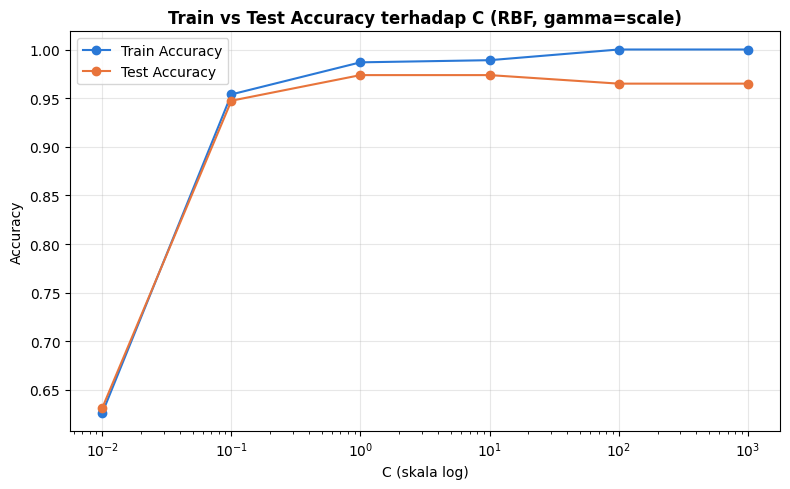

In [18]:
# Plot grafik akurasi training vs testing terhadap nilai C (gunakan sumbu x logaritmik) dalam satu chart.
# Amati pada nilai C berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

plt.figure(figsize=(8, 5))
plt.plot(C_list, train_acc, marker='o', label='Train Accuracy', color='#2a78d6')
plt.plot(C_list, test_acc, marker='o', label='Test Accuracy', color='#e8743b')
plt.xscale('log')
plt.xlabel('C (skala log)')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy terhadap C (RBF, gamma=scale)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Tambahan: Pengaruh Gamma

`gamma` mengatur seberapa jauh pengaruh satu titik data. Gamma kecil membuat pengaruhnya luas sehingga batas keputusan halus, sedangkan gamma besar membuat pengaruhnya sangat lokal sehingga batas keputusan bisa berliku mengikuti tiap titik. Di sini `C` ditetapkan = 1 agar perbandingan fokus pada pengaruh gamma. Sebagai pembanding, `gamma='scale'` pada data ini bernilai 1 / (jumlah fitur × varians data) = 1/30 ≈ 0.033.

,gamma,Train Accuracy,Test Accuracy,Selisih (Train - Test),Jumlah Support Vector
0,0.0001,0.7846,0.7719,0.0127,328
1,0.0010,0.9495,0.9386,0.0109,176
2,0.0100,0.9758,0.9561,0.0197,96
3,0.1000,0.9890,0.9298,0.0592,194
4,1.0000,1.0000,0.6316,0.3684,455
5,10.0000,1.0000,0.6316,0.3684,455


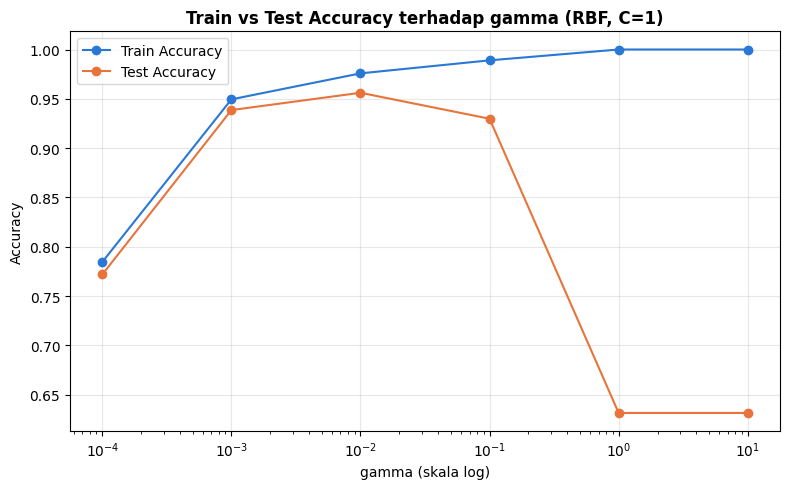

In [19]:
gamma_list = [0.0001, 0.001, 0.01, 0.1, 1, 10]
gamma_train_acc, gamma_test_acc, gamma_sv = [], [], []
for g in gamma_list:
    m = SVC(kernel='rbf', C=1.0, gamma=g)
    m.fit(X_train_scaled, y_train)
    gamma_train_acc.append(accuracy_score(y_train, m.predict(X_train_scaled)))
    gamma_test_acc.append(accuracy_score(y_test, m.predict(X_test_scaled)))
    gamma_sv.append(m.n_support_.sum())

hasil_gamma = pd.DataFrame({
    'gamma': gamma_list,
    'Train Accuracy': gamma_train_acc,
    'Test Accuracy': gamma_test_acc,
    'Selisih (Train - Test)': np.array(gamma_train_acc) - np.array(gamma_test_acc),
    'Jumlah Support Vector': gamma_sv,
})
display(hasil_gamma.round(4))

plt.figure(figsize=(8, 5))
plt.plot(gamma_list, gamma_train_acc, marker='o', label='Train Accuracy', color='#2a78d6')
plt.plot(gamma_list, gamma_test_acc, marker='o', label='Test Accuracy', color='#e8743b')
plt.xscale('log')
plt.xlabel('gamma (skala log)')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy terhadap gamma (RBF, C=1)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [20]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model kernel Linear dan RBF.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

from sklearn.metrics import precision_score, recall_score, f1_score

# Precision, Recall, dan F1 dihitung untuk kelas 1 (Malignant), yaitu kelas yang ingin dideteksi.
def hitung_metrik(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
    }

tabel_metrik = pd.DataFrame({
    'Linear': hitung_metrik(y_test, y_pred_linear),
    'RBF': hitung_metrik(y_test, y_pred_rbf),
}).T

# Model terbaik dipilih berdasarkan F1-Score kelas Malignant (gabungan precision dan recall).
best_kernel = tabel_metrik['F1-Score'].idxmax()
best_model = model_linear if best_kernel == 'Linear' else model_rbf
print('Model dengan performa terbaik:', best_kernel)
tabel_metrik.round(4)

Model dengan performa terbaik: RBF


,Accuracy,Precision,Recall,F1-Score
Linear,0.9649,1.0,0.9048,0.950
RBF,0.9737,1.0,0.9286,0.963


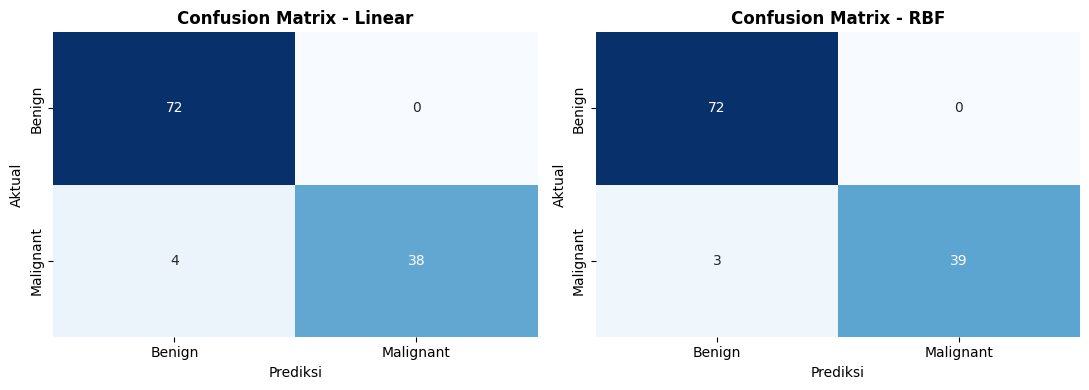

In [21]:
# Tampilkan Confusion Matrix untuk model kernel Linear dan RBF dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.

from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (nama, pred) in zip(axes, [('Linear', y_pred_linear), ('RBF', y_pred_rbf)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    ax.set_title(f'Confusion Matrix - {nama}', fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
plt.tight_layout()
plt.show()

In [22]:
# Tampilkan jumlah support vectors dari model dengan performa terbaik (atribut model.support_vectors_ atau model.n_support_).
# Bandingkan jumlah support vectors antara model Linear dan RBF.

tabel_sv = pd.DataFrame({
    'Kernel': ['Linear', 'RBF'],
    'SV kelas B': [model_linear.n_support_[0], model_rbf.n_support_[0]],
    'SV kelas M': [model_linear.n_support_[1], model_rbf.n_support_[1]],
    'Total SV': [model_linear.support_vectors_.shape[0], model_rbf.support_vectors_.shape[0]],
})
tabel_sv['% dari Train Set'] = tabel_sv['Total SV'] / len(X_train) * 100

print(f'Model terbaik ({best_kernel}) memiliki {best_model.support_vectors_.shape[0]} support vectors '
      f'dari {len(X_train)} data train.')
tabel_sv.round(2)

Model terbaik (RBF) memiliki 107 support vectors dari 455 data train.


,Kernel,SV kelas B,SV kelas M,Total SV,% dari Train Set
0,Linear,19,19,38,8.35
1,RBF,50,57,107,23.52


Variansi yang dijelaskan PC1 + PC2: 63.1%
Test Accuracy model 2D (hanya untuk visualisasi): 0.9298


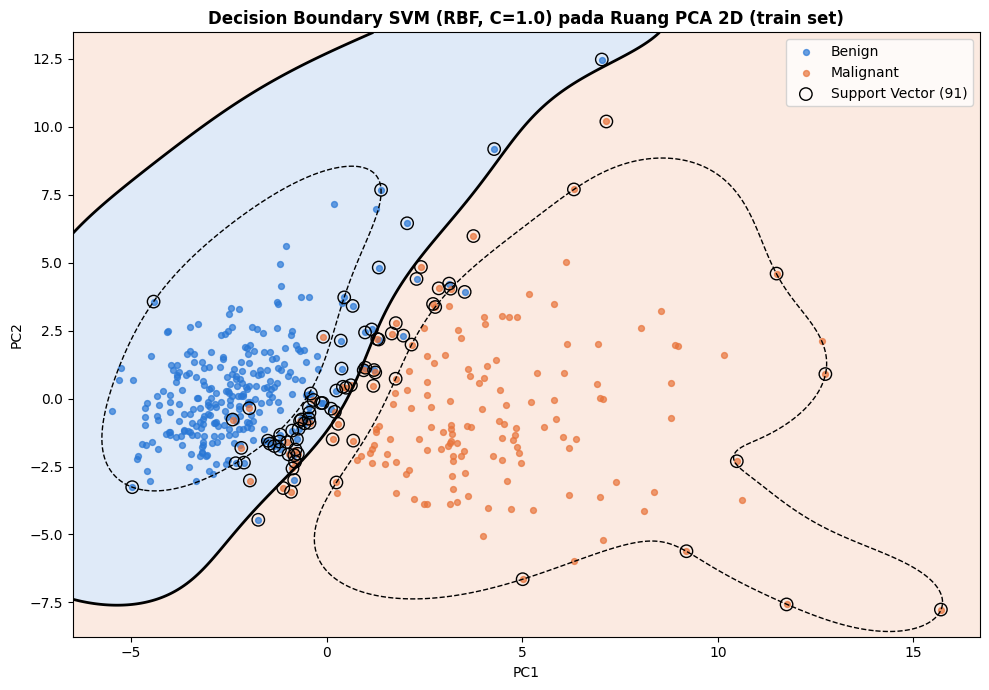

In [23]:
# Jika memungkinkan, pilih dua fitur (atau reduksi dimensi dengan PCA ke 2D) lalu visualisasikan decision boundary
# beserta margin dan support vectors dari model terbaik.

from sklearn.decomposition import PCA

# Data 30 dimensi direduksi menjadi 2 komponen utama (PCA di-fit pada train set saja).
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print('Variansi yang dijelaskan PC1 + PC2: %.1f%%' % (pca.explained_variance_ratio_.sum() * 100))

# Model baru dilatih di ruang 2D dengan kernel dan C yang sama seperti model terbaik.
# Model ini hanya untuk visualisasi, karena model asli bekerja di ruang 30 dimensi.
model_2d = SVC(kernel=best_model.kernel, C=best_model.C, gamma=best_model.gamma)
model_2d.fit(X_train_pca, y_train)
print('Test Accuracy model 2D (hanya untuk visualisasi): %.4f' % accuracy_score(y_test, model_2d.predict(X_test_pca)))

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
Z = model_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z > 0, alpha=0.15, colors=['#2a78d6', '#e8743b'])
# Garis utuh = decision boundary (f(x) = 0), garis putus-putus = margin (f(x) = -1 dan +1)
plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'], linewidths=[1, 2, 1])
for kelas, warna, label in [(0, '#2a78d6', 'Benign'), (1, '#e8743b', 'Malignant')]:
    mask = (y_train == kelas).values
    plt.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], c=warna, s=18, alpha=0.7, label=label)
plt.scatter(model_2d.support_vectors_[:, 0], model_2d.support_vectors_[:, 1], s=80,
            facecolors='none', edgecolors='k', linewidths=1, label=f'Support Vector ({len(model_2d.support_vectors_)})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Decision Boundary SVM ({best_kernel}, C={best_model.C}) pada Ruang PCA 2D (train set)', fontweight='bold')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa SVM dengan kernel Linear vs RBF. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian, dikaitkan dengan bentuk sebaran data pada EDA?
- Jelaskan temuan dari eksperimen regularisasi (nilai `C`). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Bandingkan jumlah support vectors antara model Linear dan RBF. Apa hubungan jumlah support vectors dengan kompleksitas batas keputusan yang terbentuk?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

### Jawaban Analisis

**1. Linear vs RBF (`C=1`)**

| Kernel | Test Acc | Recall | F1-Score | Jumlah SV |
|---|---|---|---|---|
| Linear | 0.9649 | 0.9048 | 0.9500 | 38 |
| RBF | **0.9737** | **0.9286** | **0.9630** | 107 |

- RBF sedikit lebih baik, tetapi selisihnya hanya 1 sampel: Linear melewatkan 4 kasus Malignant, RBF 3. Keduanya tidak punya false positive.
- Perbedaannya tidak signifikan karena dari EDA data sudah hampir terpisah secara linear. Histogram `radius`, `area`, dan `concave points` serta scatter `radius_worst` vs `concave points_worst` hanya sedikit tumpang tindih, jadi kernel Linear sudah cukup.
- Tanpa scaling, test accuracy turun (Linear 0.9211, RBF 0.9035) karena fitur berskala besar seperti `area_worst` mendominasi perhitungan jarak.

**2. Pengaruh C (RBF, `gamma='scale'`)**

- **C = 0.01 (underfitting):** semua data ditebak Benign (train 0.626, test 0.632).
- **C = 1–10 (terbaik):** test accuracy 0.9737, selisih train-test hanya ~1.5%.
- **C ≥ 100 (mulai overfitting):** train mencapai 100%, tetapi test turun ke 0.9649. Di grafik, garis train naik ke 1.0 sementara garis test turun, sehingga jaraknya melebar.
- Gamma lebih sensitif dari C. Pada gamma ≥ 1, train 100% tetapi test hanya 0.6316 (overfitting ekstrem), dan semua data train menjadi support vector.

**3. Support Vector**

- Linear memakai 38 SV (8.4% data train), RBF memakai 107 SV (23.5%).
- Kernel Linear hanya butuh sedikit titik untuk membentuk satu hyperplane lurus. Kernel RBF butuh lebih banyak SV untuk membentuk batas yang melengkung, jadi batas keputusannya lebih kompleks.
- Jumlah SV juga tinggi saat underfitting (C = 0.01 → 341 SV, karena margin terlalu lebar) dan saat overfitting ekstrem (gamma ≥ 1 → 455 SV). Jadi SV yang banyak tidak selalu berarti model lebih baik.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba kernel Polynomial, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

### Kesimpulan

- Model terbaik adalah RBF (`C=1`) dengan accuracy 0.9737 dan F1 0.963. Linear hampir sama (selisih 1 sampel) dan lebih sederhana (38 SV vs 107).
- Feature scaling wajib untuk SVM. Tanpa scaling, accuracy RBF turun ke 0.9035.
- Nilai C terbaik ada di 1–10. C terlalu kecil menyebabkan underfitting, C ≥ 100 mulai overfitting, dan gamma yang terlalu besar menyebabkan overfitting ekstrem.

### Saran

1. Gunakan `GridSearchCV` + cross-validation untuk mencari kombinasi C dan gamma terbaik.
2. Gunakan `class_weight='balanced'` atau scoring recall agar kasus kanker yang terlewat (false negative) berkurang.
3. Coba kernel Polynomial dan bandingkan dengan model lain seperti Logistic Regression atau Random Forest.